In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 4.6 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, gc, joblib

from collections import defaultdict
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, roc_curve
)
import category_encoders as ce

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', palette='colorblind')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 50)

print('All imports loaded.')

All imports loaded.


---
## Section 1 — Data Loading

Load the flight dataset with pre-merged weather features directly from Kaggle. The dataset contains 32 original flight columns plus 12 weather columns (6 for the origin airport, 6 for the destination airport).

In [4]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    'huskydawg/flight-cancellation2019-2023-full-with-weather',
    'flights_with_weather.csv',
)

df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])
df['CANCELLED'] = df['CANCELLED'].fillna(0).astype(int)

print(f'Dataset shape: {df.shape}')
print(f'Date range:    {df["FL_DATE"].min().date()} to {df["FL_DATE"].max().date()}')
print(f'Memory usage:  {df.memory_usage(deep=True).sum() / 1e6:.0f} MB')
display(df.head())

/tmp/ipykernel_528/2675567350.py:4: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'flight-cancellation2019-2023-full-with-weather' dataset.
Dataset shape: (3234981, 44)
Date range:    2019-01-01 to 2023-12-31
Memory usage:  2397 MB


,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,CANCELLATION_CODE,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT,origin_temp_mean_c,origin_wind_speed_max_kmh,origin_pressure_msl_hpa,origin_humidity_pct,origin_precipitation_mm,origin_snowfall_cm,dest_temp_mean_c,dest_wind_speed_max_kmh,dest_pressure_msl_hpa,dest_humidity_pct,dest_precipitation_mm,dest_snowfall_cm
0,2019-01-01,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1404,LAX,"Los Angeles, CA",SLC,"Salt Lake City, UT",601,600.0,-1.0,16.0,616.0,848.0,4.0,900,852.0,-8.0,0,NaN,0.0,119.0,112.0,92.0,590.0,NaN,NaN,NaN,NaN,NaN,9.4,26.3,1019.2,33.0,0.0,0.00,-9.7,16.4,1033.0,56.0,0.0,0.00
1,2019-01-01,SkyWest Airlines Inc.,SkyWest Airlines Inc.: OO,OO,20304,5016,LWB,"Lewisburg, WV",ORD,"Chicago, IL",1745,1846.0,61.0,11.0,1857.0,1929.0,43.0,1844,2012.0,88.0,0,NaN,0.0,119.0,146.0,92.0,489.0,0.0,0.0,27.0,0.0,61.0,9.0,20.7,1018.1,85.0,1.8,0.00,-1.9,14.2,1024.7,83.0,0.3,0.14
2,2019-01-01,Mesa Airlines Inc.,Mesa Airlines Inc.: YV,YV,20378,5733,LFT,"Lafayette, LA",DFW,"Dallas/Fort Worth, TX",626,623.0,-3.0,19.0,642.0,745.0,11.0,800,756.0,-4.0,0,NaN,0.0,94.0,93.0,63.0,351.0,NaN,NaN,NaN,NaN,NaN,15.3,17.2,1019.7,80.0,0.8,0.00,3.4,25.5,1025.5,71.0,0.0,0.00
3,2019-01-01,Republic Airline,Republic Airline: YX,YX,20452,4660,TLH,"Tallahassee, FL",CLT,"Charlotte, NC",2023,2013.0,-10.0,13.0,2026.0,2123.0,18.0,2149,2141.0,-8.0,0,NaN,0.0,86.0,88.0,57.0,386.0,NaN,NaN,NaN,NaN,NaN,21.2,13.0,1020.5,91.0,0.0,0.00,16.7,22.5,1018.0,92.0,1.0,0.00
4,2019-01-01,SkyWest Airlines Inc.,SkyWest Airlines Inc.: OO,OO,20304,5426,DEN,"Denver, CO",ASE,"Aspen, CO",755,804.0,9.0,33.0,837.0,905.0,5.0,855,910.0,15.0,0,NaN,0.0,60.0,66.0,28.0,125.0,9.0,0.0,6.0,0.0,0.0,-12.0,11.0,1032.0,53.0,0.2,0.14,-11.0,7.8,1023.0,71.0,1.1,0.84


---
## Section 2 — Data Quality & Feature Classification

A condensed assessment focused on missing values, data leakage detection, and classifying all 44 columns into actionable categories for the ML pipeline.

In [5]:
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().mean() * 100).round(2)
}).sort_values('Missing %', ascending=False)

print('=== Missing Values Summary ===')
display(missing[missing['Missing Count'] > 0])

print('\n=== Leakage Detection ===')
print('Post-departure columns are NaN when CANCELLED=1 (proving they are only')
print('known after departure and must be dropped to prevent target leakage):\n')

cancelled = df[df['CANCELLED'] == 1]
operated = df[df['CANCELLED'] == 0]

leak_check = pd.DataFrame({
    'NaN % (Cancelled)': (cancelled.isnull().mean() * 100).round(1),
    'NaN % (Operated)': (operated.isnull().mean() * 100).round(1),
})
display(leak_check[leak_check['NaN % (Cancelled)'] > 90].sort_values(
    'NaN % (Cancelled)', ascending=False))

del cancelled, operated
gc.collect()

=== Missing Values Summary ===


,Missing Count,Missing %
CANCELLATION_CODE,3149230,97.35
DELAY_DUE_WEATHER,2665058,82.38
DELAY_DUE_CARRIER,2665058,82.38
DELAY_DUE_NAS,2665058,82.38
DELAY_DUE_SECURITY,2665058,82.38
DELAY_DUE_LATE_AIRCRAFT,2665058,82.38
ELAPSED_TIME,93203,2.88
ARR_DELAY,93203,2.88
AIR_TIME,93203,2.88
ARR_TIME,86598,2.68



=== Leakage Detection ===
Post-departure columns are NaN when CANCELLED=1 (proving they are only
known after departure and must be dropped to prevent target leakage):



,NaN % (Cancelled),NaN % (Operated)
ARR_TIME,100.0,0.0
TAXI_IN,100.0,0.0
WHEELS_ON,100.0,0.0
DELAY_DUE_CARRIER,100.0,81.9
AIR_TIME,100.0,0.2
ELAPSED_TIME,100.0,0.2
ARR_DELAY,100.0,0.2
DELAY_DUE_WEATHER,100.0,81.9
DELAY_DUE_NAS,100.0,81.9
DELAY_DUE_SECURITY,100.0,81.9


99

### Feature Classification

Every column is explicitly assigned to one of five categories. Only **pre-departure** and **weather** features enter the ML pipeline.

| Category | Columns | Action |
|---|---|---|
| **Target** | `CANCELLED` | Extract as `y` |
| **Pre-departure (usable)** | `ORIGIN`, `DEST`, `AIRLINE_CODE`, `CRS_DEP_TIME`, `CRS_ELAPSED_TIME`, `DISTANCE`, `FL_DATE` | Keep — engineer & encode |
| **Weather (usable)** | `origin_temp_mean_c`, `origin_wind_speed_max_kmh`, `origin_pressure_msl_hpa`, `origin_humidity_pct`, `origin_precipitation_mm`, `origin_snowfall_cm`, `dest_temp_mean_c`, `dest_wind_speed_max_kmh`, `dest_pressure_msl_hpa`, `dest_humidity_pct`, `dest_precipitation_mm`, `dest_snowfall_cm` | Keep — impute & scale |
| **Post-departure (leak)** | `DEP_TIME`, `DEP_DELAY`, `TAXI_OUT`, `WHEELS_OFF`, `WHEELS_ON`, `TAXI_IN`, `ARR_TIME`, `ARR_DELAY`, `ELAPSED_TIME`, `AIR_TIME`, `DELAY_DUE_*`, `CANCELLATION_CODE`, `DIVERTED` | **Drop** — only known after departure |
| **Redundant identifiers** | `AIRLINE`, `AIRLINE_DOT`, `DOT_CODE`, `FL_NUMBER`, `ORIGIN_CITY`, `DEST_CITY`, `CRS_ARR_TIME` | **Drop** — duplicate encodings or not predictive |
| **Engineered (ablation)** | `IS_COVID` (derived: 1 if FL_DATE in Mar 2020 – Jun 2021, else 0) | Exported in two versions (with / without) for ablation study |

---
## Section 3 — Feature Engineering & Preprocessing Pipeline

The pipeline follows a strict order to prevent any form of data leakage:

1. Drop post-departure and redundant columns
2. Engineer temporal features with cyclical encoding
3. Temporal train / validation / test split (no random shuffling)
4. Target-encode high-cardinality categoricals (fit on train only)
5. Impute missing values and scale all features (fit on train only)

In [6]:
# ── 3.1 Save route info for the baseline model, then drop columns ──

y = df['CANCELLED'].values
route_origin = df['ORIGIN'].astype(str).str.strip().values
route_dest   = df['DEST'].astype(str).str.strip().values

LEAK_COLS = [
    'DEP_TIME', 'DEP_DELAY', 'TAXI_OUT', 'WHEELS_OFF', 'WHEELS_ON',
    'TAXI_IN', 'ARR_TIME', 'ARR_DELAY', 'ELAPSED_TIME', 'AIR_TIME',
    'DELAY_DUE_CARRIER', 'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS',
    'DELAY_DUE_SECURITY', 'DELAY_DUE_LATE_AIRCRAFT',
    'CANCELLATION_CODE', 'DIVERTED',
]

REDUNDANT_COLS = [
    'AIRLINE', 'AIRLINE_DOT', 'DOT_CODE', 'FL_NUMBER',
    'ORIGIN_CITY', 'DEST_CITY', 'CRS_ARR_TIME',
]

df = df.drop(columns=LEAK_COLS + REDUNDANT_COLS + ['CANCELLED'])

print(f'After dropping leakage/redundant + target: {df.shape}')
print(f'Remaining columns: {df.columns.tolist()}')

After dropping leakage/redundant + target: (3234981, 19)
Remaining columns: ['FL_DATE', 'AIRLINE_CODE', 'ORIGIN', 'DEST', 'CRS_DEP_TIME', 'CRS_ELAPSED_TIME', 'DISTANCE', 'origin_temp_mean_c', 'origin_wind_speed_max_kmh', 'origin_pressure_msl_hpa', 'origin_humidity_pct', 'origin_precipitation_mm', 'origin_snowfall_cm', 'dest_temp_mean_c', 'dest_wind_speed_max_kmh', 'dest_pressure_msl_hpa', 'dest_humidity_pct', 'dest_precipitation_mm', 'dest_snowfall_cm']


In [7]:
# ── 3.2 Temporal feature extraction & cyclical encoding ──
#
# Time is cyclical: hour 23 is only 1 hour from hour 0, but as raw
# integers a linear model sees them 23 apart. Sine/cosine encoding
# preserves the circular distance.

df['MONTH']       = df['FL_DATE'].dt.month
df['DAY_OF_WEEK'] = df['FL_DATE'].dt.dayofweek
df['DEP_HOUR']    = (df['CRS_DEP_TIME'].fillna(0) // 100).clip(0, 23).astype(int)

df['MONTH_SIN'] = np.sin(2 * np.pi * df['MONTH'] / 12)
df['MONTH_COS'] = np.cos(2 * np.pi * df['MONTH'] / 12)
df['DOW_SIN']   = np.sin(2 * np.pi * df['DAY_OF_WEEK'] / 7)
df['DOW_COS']   = np.cos(2 * np.pi * df['DAY_OF_WEEK'] / 7)
df['HOUR_SIN']  = np.sin(2 * np.pi * df['DEP_HOUR'] / 24)
df['HOUR_COS']  = np.cos(2 * np.pi * df['DEP_HOUR'] / 24)
df['IS_WEEKEND'] = (df['DAY_OF_WEEK'] >= 5).astype(int)
df['IS_COVID']   = ((df['FL_DATE'] >= '2020-03-01') & (df['FL_DATE'] <= '2021-06-30')).astype(int)

df = df.drop(columns=['CRS_DEP_TIME', 'MONTH', 'DAY_OF_WEEK', 'DEP_HOUR'])

print(f'After feature engineering: {df.shape}')
print(f'Engineered features: MONTH_SIN/COS, DOW_SIN/COS, HOUR_SIN/COS, IS_WEEKEND, IS_COVID')
print(f'IS_COVID distribution: {df["IS_COVID"].value_counts().to_dict()}')

After feature engineering: (3234981, 26)
Engineered features: MONTH_SIN/COS, DOW_SIN/COS, HOUR_SIN/COS, IS_WEEKEND, IS_COVID
IS_COVID distribution: {0: 2608922, 1: 626059}


### 3.3 Strict Temporal Split

We split purely by date to simulate real-world deployment — no random shuffling:

| Split | Date Range | Purpose |
|---|---|---|
| **Train** | 2019-01-01 to 2022-06-30 | Learn from past (includes COVID shock) |
| **Validation** | 2022-07-01 to 2022-12-31 | Tune thresholds & early stopping |
| **Test** | 2023-01-01 to 2023-12-31 | Final unseen evaluation |

This prevents future-leakage where the model learns from 2023 data to predict 2022 flights.

In [8]:
train_mask = (df['FL_DATE'] < '2022-07-01').values
val_mask   = ((df['FL_DATE'] >= '2022-07-01') & (df['FL_DATE'] < '2023-01-01')).values
test_mask  = (df['FL_DATE'] >= '2023-01-01').values

X_train = df[train_mask].drop(columns=['FL_DATE']).reset_index(drop=True)
X_val   = df[val_mask].drop(columns=['FL_DATE']).reset_index(drop=True)
X_test  = df[test_mask].drop(columns=['FL_DATE']).reset_index(drop=True)

y_train = y[train_mask]
y_val   = y[val_mask]
y_test  = y[test_mask]

train_origin = route_origin[train_mask]
train_dest   = route_dest[train_mask]
val_origin   = route_origin[val_mask]
val_dest     = route_dest[val_mask]
test_origin  = route_origin[test_mask]
test_dest    = route_dest[test_mask]

del df
gc.collect()

for name, X_s, y_s in [('Train', X_train, y_train),
                        ('Val',   X_val,   y_val),
                        ('Test',  X_test,  y_test)]:
    rate = y_s.mean() * 100
    print(f'{name:5s}: {len(X_s):>10,} rows  |  cancellation rate: {rate:.2f}%')

Train:  2,186,803 rows  |  cancellation rate: 2.92%
Val  :    349,591 rows  |  cancellation rate: 2.16%
Test :    698,587 rows  |  cancellation rate: 2.06%


In [9]:
#  3.4 Target Encoding
#
# Replaces high-cardinality categoricals (300+ airports, 20+ airlines)
# with the historical cancellation rate for that category. Uses 5-fold
# internal CV during fit to prevent the training rows from leaking their
# own target into the encoding. Unseen categories fall back to the
# global mean.
from sklearn.model_selection import StratifiedKFold
import category_encoders as ce

cat_cols = ['ORIGIN', 'DEST', 'AIRLINE_CODE']
K = 5

# Save original categories BEFORE they get overwritten
X_train_cat_original = X_train[cat_cols].copy()

X_train_encoded = X_train.copy()
skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)

for fold_idx, (fit_idx, oof_idx) in enumerate(skf.split(X_train, y_train)):
    fold_encoder = ce.TargetEncoder(cols=cat_cols, smoothing=1.0)
    fold_encoder.fit(X_train.iloc[fit_idx][cat_cols], y_train[fit_idx])
    X_train_encoded.iloc[oof_idx, X_train_encoded.columns.get_indexer(cat_cols)] = (
        fold_encoder.transform(X_train.iloc[oof_idx][cat_cols]).values
    )

X_train[cat_cols] = X_train_encoded[cat_cols]

# Fit final encoder on ORIGINAL strings, not the encoded floats
encoder = ce.TargetEncoder(cols=cat_cols, smoothing=1.0)
encoder.fit(X_train_cat_original, y_train)

X_val[cat_cols]  = encoder.transform(X_val[cat_cols])
X_test[cat_cols] = encoder.transform(X_test[cat_cols])

del X_train_encoded, X_train_cat_original

print(f'Target-encoded (K={K}): {cat_cols}')
print(f'\nEncoded ORIGIN values (train sample):')
display(X_train['ORIGIN'].describe().round(4))

Target-encoded (K=5): ['ORIGIN', 'DEST', 'AIRLINE_CODE']

Encoded ORIGIN values (train sample):


,ORIGIN
count,2.186803e+06
unique,1.660000e+03
top,1.760000e-02
freq,2.302800e+04


In [10]:
# ── 3.5 Imputation  ──

impute_cols = ['CRS_ELAPSED_TIME', 'DISTANCE']

imputer = SimpleImputer(strategy='median')
X_train[impute_cols] = imputer.fit_transform(X_train[impute_cols])
X_val[impute_cols]   = imputer.transform(X_val[impute_cols])
X_test[impute_cols]  = imputer.transform(X_test[impute_cols])

# ── 3.6 Non-numeric safeguard ──

non_numeric = X_train.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric:
    print(f'Coercing non-numeric columns to float: {non_numeric}')
    for col in non_numeric:
        X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
        X_val[col]   = pd.to_numeric(X_val[col], errors='coerce')
        X_test[col]  = pd.to_numeric(X_test[col], errors='coerce')

# ── 3.7 Standard Scaling ──

feature_names = X_train.columns.tolist()
scaler = StandardScaler()

X_train_all = pd.DataFrame(
    scaler.fit_transform(X_train), columns=feature_names)
X_val_all = pd.DataFrame(
    scaler.transform(X_val), columns=feature_names)
X_test_all = pd.DataFrame(
    scaler.transform(X_test), columns=feature_names)

# ── With IS_COVID ──
X_train_covid = X_train_all.copy()
X_val_covid   = X_val_all.copy()
X_test_covid  = X_test_all.copy()

# ── Without IS_COVID ──
X_train_scaled = X_train_all.drop(columns=['IS_COVID'])
X_val_scaled   = X_val_all.drop(columns=['IS_COVID'])
X_test_scaled  = X_test_all.drop(columns=['IS_COVID'])

print(f'With IS_COVID:    {X_train_covid.shape[1]} features')
print(f'Without IS_COVID: {X_train_scaled.shape[1]} features')
print(f'Features (with): {X_train_covid.columns.tolist()}')
print(f'\nScaled training set (mean ~ 0, std ~ 1):')
display(X_train_covid.describe().round(3))

Coercing non-numeric columns to float: ['AIRLINE_CODE', 'ORIGIN', 'DEST']
With IS_COVID:    25 features
Without IS_COVID: 24 features
Features (with): ['AIRLINE_CODE', 'ORIGIN', 'DEST', 'CRS_ELAPSED_TIME', 'DISTANCE', 'origin_temp_mean_c', 'origin_wind_speed_max_kmh', 'origin_pressure_msl_hpa', 'origin_humidity_pct', 'origin_precipitation_mm', 'origin_snowfall_cm', 'dest_temp_mean_c', 'dest_wind_speed_max_kmh', 'dest_pressure_msl_hpa', 'dest_humidity_pct', 'dest_precipitation_mm', 'dest_snowfall_cm', 'MONTH_SIN', 'MONTH_COS', 'DOW_SIN', 'DOW_COS', 'HOUR_SIN', 'HOUR_COS', 'IS_WEEKEND', 'IS_COVID']

Scaled training set (mean ~ 0, std ~ 1):


,AIRLINE_CODE,ORIGIN,DEST,CRS_ELAPSED_TIME,DISTANCE,origin_temp_mean_c,origin_wind_speed_max_kmh,origin_pressure_msl_hpa,origin_humidity_pct,origin_precipitation_mm,origin_snowfall_cm,dest_temp_mean_c,dest_wind_speed_max_kmh,dest_pressure_msl_hpa,dest_humidity_pct,dest_precipitation_mm,dest_snowfall_cm,MONTH_SIN,MONTH_COS,DOW_SIN,DOW_COS,HOUR_SIN,HOUR_COS,IS_WEEKEND,IS_COVID
count,2186803.000,2186803.000,2186803.000,2186803.000,2186803.000,2186803.000,2186803.000,2186803.000,2186803.000,2186803.000,2186803.000,2186803.000,2186803.000,2186803.000,2186803.000,2186803.000,2186803.000,2186803.000,2186803.000,2186803.000,2186803.000,2186803.000,2186803.000,2186803.000,2186803.000
mean,-0.000,-0.000,-0.000,-0.000,-0.000,0.000,-0.000,0.000,-0.000,-0.000,-0.000,0.000,-0.000,0.000,-0.000,0.000,0.000,-0.000,-0.000,0.000,-0.000,0.000,-0.000,-0.000,-0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-1.952,-3.315,-3.461,-1.739,-1.328,-5.554,-2.348,-8.229,-3.608,-0.406,-0.133,-5.969,-2.349,-7.423,-3.601,-0.407,-0.133,-1.541,-1.397,-1.410,-1.252,-1.227,-1.161,-0.614,-0.633
25%,-0.574,-0.520,-0.536,-0.726,-0.738,-0.705,-0.738,-0.621,-0.483,-0.406,-0.133,-0.706,-0.738,-0.620,-0.480,-0.407,-0.133,-0.832,-1.207,-1.132,-1.252,-1.049,-0.909,-0.614,-0.633
50%,-0.051,0.025,0.049,-0.233,-0.263,0.118,-0.154,-0.058,0.187,-0.406,-0.133,0.117,-0.153,-0.058,0.188,-0.407,-0.133,-0.123,0.024,-0.010,-0.307,-0.241,-0.220,-0.614,-0.633
75%,0.637,0.650,0.613,0.414,0.407,0.809,0.587,0.582,0.745,-0.098,-0.133,0.819,0.589,0.582,0.746,-0.112,-0.133,1.105,0.734,1.113,0.872,1.044,0.720,1.629,1.579
max,3.145,17.793,24.588,7.928,8.587,2.567,12.428,5.128,1.805,36.928,50.840,2.566,12.441,6.605,1.804,24.709,43.559,1.296,1.445,1.390,1.397,1.434,2.600,1.629,1.579


### 3.8 Export Preprocessed Data Artifacts

We export **two versions** of the processed data for an ablation study on the COVID indicator feature:

| Version | Directory | Description |
|---|---|---|
| **With IS_COVID** | `artifacts/` | Includes the `IS_COVID` binary flag so the model can distinguish COVID-era patterns |
| **Without IS_COVID** | `artifacts_no_covid/` | Drops `IS_COVID` — the model treats COVID-era data the same as any other period |

Both share the same train/val/test temporal split, target encoding, imputation, and scaling. Teammates can train on either version and we compare final test-set performance to determine whether the COVID indicator helps.

In [11]:
def export_artifacts(out_dir, X_tr, X_v, X_te):
    """Save datasets and pipeline objects to out_dir."""
    os.makedirs(out_dir, exist_ok=True)
    X_tr.to_parquet(f'{out_dir}/X_train.parquet')
    X_v.to_parquet(f'{out_dir}/X_val.parquet')
    X_te.to_parquet(f'{out_dir}/X_test.parquet')
    pd.DataFrame({'CANCELLED': y_train}).to_parquet(f'{out_dir}/y_train.parquet')
    pd.DataFrame({'CANCELLED': y_val}).to_parquet(f'{out_dir}/y_val.parquet')
    pd.DataFrame({'CANCELLED': y_test}).to_parquet(f'{out_dir}/y_test.parquet')
    joblib.dump(encoder, f'{out_dir}/target_encoder.pkl')
    joblib.dump(scaler, f'{out_dir}/scaler.pkl')
    joblib.dump(imputer, f'{out_dir}/imputer.pkl')
    fnames = X_tr.columns.tolist()
    joblib.dump(fnames, f'{out_dir}/feature_names.pkl')
    print(f'  Exported to {out_dir}/ — {len(fnames)} features: {fnames}')

# Version 1: WITH IS_COVID
print('=== With IS_COVID ===')
export_artifacts('artifacts_with_covid', X_train_covid, X_val_covid, X_test_covid)

# Version 2: WITHOUT IS_COVID
print('\n=== Without IS_COVID ===')
export_artifacts('artifacts_no_covid', X_train_scaled, X_val_scaled, X_test_scaled)


=== With IS_COVID ===
  Exported to artifacts_with_covid/ — 25 features: ['AIRLINE_CODE', 'ORIGIN', 'DEST', 'CRS_ELAPSED_TIME', 'DISTANCE', 'origin_temp_mean_c', 'origin_wind_speed_max_kmh', 'origin_pressure_msl_hpa', 'origin_humidity_pct', 'origin_precipitation_mm', 'origin_snowfall_cm', 'dest_temp_mean_c', 'dest_wind_speed_max_kmh', 'dest_pressure_msl_hpa', 'dest_humidity_pct', 'dest_precipitation_mm', 'dest_snowfall_cm', 'MONTH_SIN', 'MONTH_COS', 'DOW_SIN', 'DOW_COS', 'HOUR_SIN', 'HOUR_COS', 'IS_WEEKEND', 'IS_COVID']

=== Without IS_COVID ===
  Exported to artifacts_no_covid/ — 24 features: ['AIRLINE_CODE', 'ORIGIN', 'DEST', 'CRS_ELAPSED_TIME', 'DISTANCE', 'origin_temp_mean_c', 'origin_wind_speed_max_kmh', 'origin_pressure_msl_hpa', 'origin_humidity_pct', 'origin_precipitation_mm', 'origin_snowfall_cm', 'dest_temp_mean_c', 'dest_wind_speed_max_kmh', 'dest_pressure_msl_hpa', 'dest_humidity_pct', 'dest_precipitation_mm', 'dest_snowfall_cm', 'MONTH_SIN', 'MONTH_COS', 'DOW_SIN', 'DOW_CO

---
## Section 4 — Class Imbalance Strategy

With a ~2.6% cancellation rate the dataset is severely imbalanced. A naive "always predict 0" model achieves 97.4% accuracy but catches zero cancellations.

**Strategy — Cost-Sensitive Learning** (no SMOTE or undersampling):
- **Sklearn models:** `class_weight='balanced'` penalises misclassified cancellations proportionally
- **XGBoost:** `scale_pos_weight = negative_count / positive_count` (~38:1)
- **Keras:** `class_weight` dictionary passed during `model.fit()`

**Primary metric:** PR-AUC — focuses exclusively on the rare positive class, unlike accuracy or ROC-AUC which are overly optimistic under severe imbalance.

Training set class distribution:
  Class 0 (operated):   2,123,017  (97.08%)
  Class 1 (cancelled):     63,786  (2.92%)
  Imbalance ratio:     33.3 : 1

Class weights exported to artifacts/class_weights.pkl


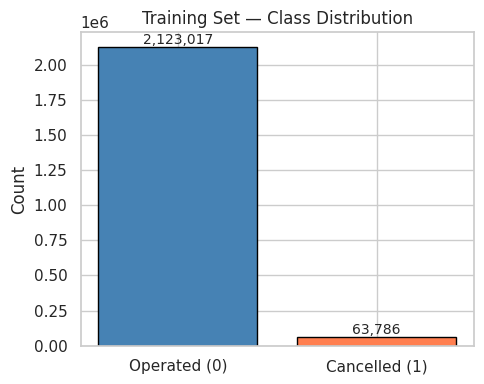

In [12]:
n_pos = int(y_train.sum())
n_neg = len(y_train) - n_pos
scale_pos_weight = n_neg / n_pos

print(f'Training set class distribution:')
print(f'  Class 0 (operated):  {n_neg:>10,}  ({n_neg/len(y_train)*100:.2f}%)')
print(f'  Class 1 (cancelled): {n_pos:>10,}  ({n_pos/len(y_train)*100:.2f}%)')
print(f'  Imbalance ratio:     {scale_pos_weight:.1f} : 1')

class_weights = {
    'scale_pos_weight': scale_pos_weight,
    'sklearn_class_weight': 'balanced',
    'keras_class_weight': {0: 1.0, 1: scale_pos_weight},
}

os.makedirs('artifacts', exist_ok=True)
joblib.dump(class_weights, 'artifacts/class_weights.pkl')
print(f'\nClass weights exported to artifacts/class_weights.pkl')

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['Operated (0)', 'Cancelled (1)'], [n_neg, n_pos],
              color=['steelblue', 'coral'], edgecolor='black')
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height(),
            f'{b.get_height():,.0f}', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Count')
ax.set_title('Training Set — Class Distribution')
plt.tight_layout()
plt.show()

---
## Section 5.1 — Neural Network (MLP) Multi-Config Evaluation

This section trains different configurations of a Keras Multilayer Perceptron (MLP) on the `X_train_no_covid.parquet` dataset to demonstrate hyperparameter tuning (capacity, batch size, learning rate).

In [ ]:
import random
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import callbacks, metrics
import os

def reset_seeds():
    seed_value = 42
    os.environ['PYTHONHASHSEED'] = str(seed_value)
    random.seed(seed_value)
    np.random.seed(seed_value)
    tf.random.set_seed(seed_value)
    tf.config.experimental.enable_op_determinism()

os.makedirs('/content/drive/MyDrive/Colab Notebooks/AML Project/NN Models (COVID)', exist_ok=True)

In [ ]:
# 1. Define the Multilayer Perceptron Architecture
from tensorflow import keras
from tensorflow.keras import layers, callbacks, metrics
import os
reset_seeds()
model_1 = keras.Sequential([
    # Input layer and First Hidden Layer (Perceptron / Multilayers)
    layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.BatchNormalization(), # Practical issues: scale and speed up training
    layers.Dropout(0.3),         # Practical issues: prevent overfitting

    # Second Hidden Layer
    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    # Output Layer (Binary classification -> sigmoid)
    layers.Dense(1, activation='sigmoid')
])

# 2. Objective functions & Backpropagation setup
model_1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        metrics.AUC(name='pr_auc', curve='PR'),
        metrics.AUC(name='roc_auc', curve='ROC')
    ]
)

print(model_1.summary())
# 3. Practical Issues: Early Stopping to prevent overfitting
early_stopping = callbacks.EarlyStopping(
    monitor='val_pr_auc',
    mode='max',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# 4. Train the Model using the Class Imbalance Strategy (from Section 4)
keras_weights = class_weights['keras_class_weight']
print(f"Training with class weights: {keras_weights}")

history_1 = model_1.fit(
    X_train_scaled.values, y_train,
    validation_data=(X_val_scaled.values, y_val),
    epochs=30,
    batch_size=1024,
    class_weight=keras_weights,
    callbacks=[early_stopping],
    verbose=1
)

# 5. Save the Model for Section 6 Evaluation
MODEL_DIR = '/content/drive/MyDrive/Colab Notebooks/AML Project/NN Models (COVID)'
os.makedirs(MODEL_DIR, exist_ok=True)
val_pr_auc_1 = max(history_1.history['val_pr_auc'])
print(f'Final val_pr_auc: {val_pr_auc_1:.4f}')
model_path = os.path.join(MODEL_DIR, 'mlp_model1.keras')
model_1.save(model_path)
print(f"\nModel saved to {model_path}")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 3,905 (15.25 KB)

 Non-trainable params: 192 (768.00 B)

None
Training with class weights: {0: 1.0, 1: 33.28343210108801}
Epoch 1/30
2136/2136 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 1.1614 - pr_auc: 0.1017 - roc_auc: 0.7476 - val_loss: 0.3400 - val_pr_auc: 0.1129 - val_roc_auc: 0.7172
Epoch 2/30
2136/2136 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 1.0933 - pr_auc: 0.1309 - roc_auc: 0.7826 - val_loss: 0.3500 - val_pr_auc: 0.1209 - val_roc_auc: 0.7274
Epoch 3/30
2136/2136 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 1.0740 - pr_auc: 0.1380 - roc_auc: 0.7920 - val_loss: 0.3433 - val_pr_auc: 0.1235 - val_roc_auc: 0.7408
Epoch 4/30
2136/2136 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 1.0658 - pr_auc: 0.1427 - roc_auc: 0.7960 - val_loss: 0.3458 - val_pr_auc: 0.1255 - val_roc_auc: 0.7388
Epoch 5/30
2136/2136 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 1.0601 - pr_auc: 0.1459 - roc_auc: 0.7985 - val_loss: 0.3535 - val_pr_auc: 0.1306 - val_roc_auc: 0.7429
Epoch 6/30
2136/2136 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 1.0562 - pr_auc: 0.1473 - roc_auc: 0.

In [ ]:
## A different configuration Training MLP Config 2: [128, 64], lr=0.001, bs=256
# 1. Define the Multilayer Perceptron Architecture
from tensorflow import keras
from tensorflow.keras import layers, callbacks, metrics
import os
reset_seeds()
model_2 = keras.Sequential([
    # Input layer and First Hidden Layer (Perceptron / Multilayers)
    layers.Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.BatchNormalization(), # Practical issues: scale and speed up training
    layers.Dropout(0.3),         # Practical issues: prevent overfitting

    # Second Hidden Layer
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    # Output Layer (Binary classification -> sigmoid)
    layers.Dense(1, activation='sigmoid')
])

# 2. Objective functions & Backpropagation setup
model_2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        metrics.AUC(name='pr_auc', curve='PR'),
        metrics.AUC(name='roc_auc', curve='ROC')
    ]
)

print(model_2.summary())

# 3. Practical Issues: Early Stopping to prevent overfitting
early_stopping = callbacks.EarlyStopping(
    monitor='val_pr_auc',
    mode='max',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# 4. Train the Model using the Class Imbalance Strategy (from Section 4)
keras_weights = class_weights['keras_class_weight']
print(f"Training with class weights: {keras_weights}")

history_2 = model_2.fit(
    X_train_scaled.values, y_train,
    validation_data=(X_val_scaled.values, y_val),
    epochs=30,
    batch_size=256,
    class_weight=keras_weights,
    callbacks=[early_stopping],
    verbose=1
)

# 5. Save the Model for Section 6 Evaluation
MODEL_DIR = '/content/drive/MyDrive/Colab Notebooks/AML Project/NN Models (COVID)'
os.makedirs(MODEL_DIR, exist_ok=True)
val_pr_auc_2 = max(history_2.history['val_pr_auc'])
print(f'Final val_pr_auc: {val_pr_auc_2:.4f}')
model_path = os.path.join(MODEL_DIR, 'mlp_model2.keras')
model_2.save(model_path)
print(f"\nModel saved to {model_path}")

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 128)            │         3,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 11,905 (46.50 KB)

 Non-trainable params: 384 (1.50 KB)

None
Training with class weights: {0: 1.0, 1: 33.28343210108801}
Epoch 1/30
8543/8543 ━━━━━━━━━━━━━━━━━━━━ 67s 8ms/step - loss: 1.1093 - pr_auc: 0.1192 - roc_auc: 0.7755 - val_loss: 0.3590 - val_pr_auc: 0.1295 - val_roc_auc: 0.7242
Epoch 2/30
8543/8543 ━━━━━━━━━━━━━━━━━━━━ 63s 7ms/step - loss: 1.0606 - pr_auc: 0.1455 - roc_auc: 0.7982 - val_loss: 0.3428 - val_pr_auc: 0.1375 - val_roc_auc: 0.7416
Epoch 3/30
8543/8543 ━━━━━━━━━━━━━━━━━━━━ 64s 7ms/step - loss: 1.0474 - pr_auc: 0.1521 - roc_auc: 0.8041 - val_loss: 0.3447 - val_pr_auc: 0.1438 - val_roc_auc: 0.7403
Epoch 4/30
8543/8543 ━━━━━━━━━━━━━━━━━━━━ 82s 8ms/step - loss: 1.0397 - pr_auc: 0.1567 - roc_auc: 0.8077 - val_loss: 0.3393 - val_pr_auc: 0.1471 - val_roc_auc: 0.7424
Epoch 5/30
8543/8543 ━━━━━━━━━━━━━━━━━━━━ 63s 7ms/step - loss: 1.0337 - pr_auc: 0.1592 - roc_auc: 0.8104 - val_loss: 0.3327 - val_pr_auc: 0.1457 - val_roc_auc: 0.7406
Epoch 6/30
8543/8543 ━━━━━━━━━━━━━━━━━━━━ 64s 7ms/step - loss: 1.0285 - pr_auc: 0.1617 - roc_auc: 0.

In [ ]:
## Configuration #3 Training MLP Config 3: [128, 64], lr=0.0001, bs=256
# 1. Define the Multilayer Perceptron Architecture
from tensorflow import keras
from tensorflow.keras import layers, callbacks, metrics
import os
reset_seeds()
model_3 = keras.Sequential([
    # Input layer and First Hidden Layer (Perceptron / Multilayers)
    layers.Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.BatchNormalization(), # Practical issues: scale and speed up training
    layers.Dropout(0.3),         # Practical issues: prevent overfitting

    # Second Hidden Layer
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    # Output Layer (Binary classification -> sigmoid)
    layers.Dense(1, activation='sigmoid')
])

# 2. Objective functions & Backpropagation setup
model_3.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=[
        metrics.AUC(name='pr_auc', curve='PR'),
        metrics.AUC(name='roc_auc', curve='ROC')
    ]
)

print(model_3.summary())
# 3. Practical Issues: Early Stopping to prevent overfitting
early_stopping = callbacks.EarlyStopping(
    monitor='val_pr_auc',
    mode='max',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# 4. Train the Model using the Class Imbalance Strategy (from Section 4)
keras_weights = class_weights['keras_class_weight']
print(f"Training with class weights: {keras_weights}")

history_3 = model_3.fit(
    X_train_scaled.values, y_train,
    validation_data=(X_val_scaled.values, y_val),
    epochs=30,
    batch_size=256,
    class_weight=keras_weights,
    callbacks=[early_stopping],
    verbose=1
)

# 5. Save the Model for Section 6 Evaluation
MODEL_DIR = '/content/drive/MyDrive/Colab Notebooks/AML Project/NN Models (COVID)'
os.makedirs(MODEL_DIR, exist_ok=True)
val_pr_auc_3 = max(history_3.history['val_pr_auc'])
print(f'Final val_pr_auc: {val_pr_auc_3:.4f}')
model_path = os.path.join(MODEL_DIR, 'mlp_model3.keras')
model_3.save(model_path)
print(f"\nModel saved to {model_path}")

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 128)            │         3,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 11,905 (46.50 KB)

 Non-trainable params: 384 (1.50 KB)

None
Training with class weights: {0: 1.0, 1: 33.28343210108801}
Epoch 1/30
8543/8543 ━━━━━━━━━━━━━━━━━━━━ 66s 8ms/step - loss: 1.2391 - pr_auc: 0.0849 - roc_auc: 0.7188 - val_loss: 0.3534 - val_pr_auc: 0.1058 - val_roc_auc: 0.7276
Epoch 2/30
8543/8543 ━━━━━━━━━━━━━━━━━━━━ 63s 7ms/step - loss: 1.1225 - pr_auc: 0.1191 - roc_auc: 0.7674 - val_loss: 0.3442 - val_pr_auc: 0.1184 - val_roc_auc: 0.7258
Epoch 3/30
8543/8543 ━━━━━━━━━━━━━━━━━━━━ 64s 8ms/step - loss: 1.0982 - pr_auc: 0.1326 - roc_auc: 0.7800 - val_loss: 0.3422 - val_pr_auc: 0.1278 - val_roc_auc: 0.7282
Epoch 4/30
8543/8543 ━━━━━━━━━━━━━━━━━━━━ 63s 7ms/step - loss: 1.0837 - pr_auc: 0.1389 - roc_auc: 0.7872 - val_loss: 0.3385 - val_pr_auc: 0.1287 - val_roc_auc: 0.7332
Epoch 5/30
8543/8543 ━━━━━━━━━━━━━━━━━━━━ 64s 7ms/step - loss: 1.0743 - pr_auc: 0.1439 - roc_auc: 0.7916 - val_loss: 0.3419 - val_pr_auc: 0.1318 - val_roc_auc: 0.7343
Epoch 6/30
8543/8543 ━━━━━━━━━━━━━━━━━━━━ 63s 7ms/step - loss: 1.0668 - pr_auc: 0.1469 - roc_auc: 0.

In [ ]:
## Configuration #4: Deeper Architecture [256, 128, 64], lr=0.0001, bs=256
# 1. Define the Multilayer Perceptron Architecture
from tensorflow import keras
from tensorflow.keras import layers, callbacks, metrics
import os
reset_seeds()
model_4 = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.BatchNormalization(), layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(), layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(), layers.Dropout(0.3),

    layers.Dense(1, activation='sigmoid')
])

# 2. Objective functions & Backpropagation setup
model_4.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=[
        metrics.AUC(name='pr_auc', curve='PR'),
        metrics.AUC(name='roc_auc', curve='ROC')
    ]
)

print(model_4.summary())
# 3. Practical Issues: Early Stopping to prevent overfitting
early_stopping = callbacks.EarlyStopping(
    monitor='val_pr_auc',
    mode='max',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# 4. Train the Model using the Class Imbalance Strategy (from Section 4)
keras_weights = class_weights['keras_class_weight']
print(f"Training with class weights: {keras_weights}")

history_4 = model_4.fit(
    X_train_scaled.values, y_train,
    validation_data=(X_val_scaled.values, y_val),
    epochs=30,
    batch_size=256,
    class_weight=keras_weights,
    callbacks=[early_stopping],
    verbose=1
)

# 5. Save the Model for Section 6 Evaluation
MODEL_DIR = '/content/drive/MyDrive/Colab Notebooks/AML Project/NN Models (COVID)'
os.makedirs(MODEL_DIR, exist_ok=True)
val_pr_auc_4 = max(history_4.history['val_pr_auc'])
print(f'Final val_pr_auc: {val_pr_auc_4:.4f}')
model_path = os.path.join(MODEL_DIR, 'mlp_model4.keras')
model_4.save(model_path)
print(f"\nModel saved to {model_path}")

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_25 (Dense)                │ (None, 256)            │         6,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,409 (193.00 KB)

 Trainable params: 48,513 (189.50 KB)

 Non-trainable params: 896 (3.50 KB)

None
Training with class weights: {0: 1.0, 1: 33.28343210108801}
Epoch 1/30
8543/8543 ━━━━━━━━━━━━━━━━━━━━ 79s 9ms/step - loss: 1.2368 - pr_auc: 0.0837 - roc_auc: 0.7208 - val_loss: 0.3131 - val_pr_auc: 0.1103 - val_roc_auc: 0.7312
Epoch 2/30
8543/8543 ━━━━━━━━━━━━━━━━━━━━ 76s 9ms/step - loss: 1.1087 - pr_auc: 0.1222 - roc_auc: 0.7752 - val_loss: 0.3238 - val_pr_auc: 0.1246 - val_roc_auc: 0.7324
Epoch 3/30
8543/8543 ━━━━━━━━━━━━━━━━━━━━ 74s 9ms/step - loss: 1.0792 - pr_auc: 0.1365 - roc_auc: 0.7892 - val_loss: 0.3305 - val_pr_auc: 0.1340 - val_roc_auc: 0.7404
Epoch 4/30
8543/8543 ━━━━━━━━━━━━━━━━━━━━ 74s 9ms/step - loss: 1.0630 - pr_auc: 0.1443 - roc_auc: 0.7969 - val_loss: 0.3287 - val_pr_auc: 0.1362 - val_roc_auc: 0.7435
Epoch 5/30
8543/8543 ━━━━━━━━━━━━━━━━━━━━ 76s 9ms/step - loss: 1.0538 - pr_auc: 0.1479 - roc_auc: 0.8012 - val_loss: 0.3270 - val_pr_auc: 0.1419 - val_roc_auc: 0.7464
Epoch 6/30
8543/8543 ━━━━━━━━━━━━━━━━━━━━ 74s 9ms/step - loss: 1.0460 - pr_auc: 0.1518 - roc_auc: 0.

In [ ]:
## Configuration #5: Deeper Architecture [256, 128, 64], LR Scheduler, bs=256
# 1. Define the Multilayer Perceptron Architecture
from tensorflow import keras
from tensorflow.keras import layers, callbacks, metrics
import os
reset_seeds()
# Setup the Scheduler (Starts at 0.001, decays exponentially)
lr_schedule = keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.001,
    decay_steps=1000,
    decay_rate=0.9
)
model_5 = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.BatchNormalization(), layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(), layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(), layers.Dropout(0.3),

    layers.Dense(1, activation='sigmoid')
])

# 2. Objective functions & Backpropagation setup
model_5.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_schedule),
    loss='binary_crossentropy',
    metrics=[
        metrics.AUC(name='pr_auc', curve='PR'),
        metrics.AUC(name='roc_auc', curve='ROC')
    ]
)

print(model_5.summary())
# 3. Practical Issues: Early Stopping to prevent overfitting
early_stopping = callbacks.EarlyStopping(
    monitor='val_pr_auc',
    mode='max',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# 4. Train the Model using the Class Imbalance Strategy (from Section 4)
keras_weights = class_weights['keras_class_weight']
print(f"Training with class weights: {keras_weights}")

history_5 = model_5.fit(
    X_train_scaled.values, y_train,
    validation_data=(X_val_scaled.values, y_val),
    epochs=30,
    batch_size=256,
    class_weight=keras_weights,
    callbacks=[early_stopping],
    verbose=1
)

# 5. Save the Model for Section 6 Evaluation
MODEL_DIR = '/content/drive/MyDrive/Colab Notebooks/AML Project/NN Models (COVID)'
os.makedirs(MODEL_DIR, exist_ok=True)
val_pr_auc_5 = max(history_5.history['val_pr_auc'])
print(f'Final val_pr_auc: {val_pr_auc_5:.4f}')
model_path = os.path.join(MODEL_DIR, 'mlp_model5.keras')
model_5.save(model_path)
print(f"\nModel saved to {model_path}")

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_29 (Dense)                │ (None, 256)            │         6,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,409 (193.00 KB)

 Trainable params: 48,513 (189.50 KB)

 Non-trainable params: 896 (3.50 KB)

None
Training with class weights: {0: 1.0, 1: 33.28343210108801}
Epoch 1/30
8543/8543 ━━━━━━━━━━━━━━━━━━━━ 79s 9ms/step - loss: 1.1016 - pr_auc: 0.1214 - roc_auc: 0.7795 - val_loss: 0.3335 - val_pr_auc: 0.1380 - val_roc_auc: 0.7363
Epoch 2/30
8543/8543 ━━━━━━━━━━━━━━━━━━━━ 76s 9ms/step - loss: 1.0461 - pr_auc: 0.1508 - roc_auc: 0.8047 - val_loss: 0.3237 - val_pr_auc: 0.1420 - val_roc_auc: 0.7466
Epoch 3/30
8543/8543 ━━━━━━━━━━━━━━━━━━━━ 75s 9ms/step - loss: 1.0329 - pr_auc: 0.1578 - roc_auc: 0.8106 - val_loss: 0.3179 - val_pr_auc: 0.1428 - val_roc_auc: 0.7482
Epoch 4/30
8543/8543 ━━━━━━━━━━━━━━━━━━━━ 76s 9ms/step - loss: 1.0280 - pr_auc: 0.1602 - roc_auc: 0.8128 - val_loss: 0.3162 - val_pr_auc: 0.1420 - val_roc_auc: 0.7508
Epoch 5/30
8543/8543 ━━━━━━━━━━━━━━━━━━━━ 76s 9ms/step - loss: 1.0260 - pr_auc: 0.1610 - roc_auc: 0.8137 - val_loss: 0.3152 - val_pr_auc: 0.1411 - val_roc_auc: 0.7507
Epoch 6/30
8543/8543 ━━━━━━━━━━━━━━━━━━━━ 75s 9ms/step - loss: 1.0249 - pr_auc: 0.1628 - roc_auc: 0.

In [ ]:
## Configuration #6: Deeper Architecture [256, 128, 64], LR Scheduler, Weight Decay, bs=256
# 1. Define the Multilayer Perceptron Architecture
from tensorflow import keras
from tensorflow.keras import layers, callbacks, metrics
import os
reset_seeds()
# Setup the Scheduler (Starts at 0.001, decays exponentially)
lr_schedule = keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.001,
    decay_steps=1000,
    decay_rate=0.9
)
model_6 = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.BatchNormalization(), layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(), layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(), layers.Dropout(0.3),

    layers.Dense(1, activation='sigmoid')
])

# 2. Objective functions & Backpropagation setup
model_6.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_schedule, weight_decay=1e-4),
    loss='binary_crossentropy',
    metrics=[
        metrics.AUC(name='pr_auc', curve='PR'),
        metrics.AUC(name='roc_auc', curve='ROC')
    ]
)

print(model_6.summary())
# 3. Practical Issues: Early Stopping to prevent overfitting
early_stopping = callbacks.EarlyStopping(
    monitor='val_pr_auc',
    mode='max',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# 4. Train the Model using the Class Imbalance Strategy (from Section 4)
keras_weights = class_weights['keras_class_weight']
print(f"Training with class weights: {keras_weights}")

history_6 = model_6.fit(
    X_train_scaled.values, y_train,
    validation_data=(X_val_scaled.values, y_val),
    epochs=30,
    batch_size=256,
    class_weight=keras_weights,
    callbacks=[early_stopping],
    verbose=1
)

# 5. Save the Model for Section 6 Evaluation
MODEL_DIR = '/content/drive/MyDrive/Colab Notebooks/AML Project/NN Models (COVID)'
os.makedirs(MODEL_DIR, exist_ok=True)
val_pr_auc_6 = max(history_6.history['val_pr_auc'])
print(f'Final val_pr_auc: {val_pr_auc_6:.4f}')
model_path = os.path.join(MODEL_DIR, 'mlp_model6.keras')
model_6.save(model_path)
print(f"\nModel saved to {model_path}")

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_33 (Dense)                │ (None, 256)            │         6,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,409 (193.00 KB)

 Trainable params: 48,513 (189.50 KB)

 Non-trainable params: 896 (3.50 KB)

None
Training with class weights: {0: 1.0, 1: 33.28343210108801}
Epoch 1/30
8543/8543 ━━━━━━━━━━━━━━━━━━━━ 84s 9ms/step - loss: 1.1012 - pr_auc: 0.1220 - roc_auc: 0.7798 - val_loss: 0.3334 - val_pr_auc: 0.1369 - val_roc_auc: 0.7368
Epoch 2/30
8543/8543 ━━━━━━━━━━━━━━━━━━━━ 81s 9ms/step - loss: 1.0456 - pr_auc: 0.1507 - roc_auc: 0.8050 - val_loss: 0.3283 - val_pr_auc: 0.1417 - val_roc_auc: 0.7448
Epoch 3/30
8543/8543 ━━━━━━━━━━━━━━━━━━━━ 80s 9ms/step - loss: 1.0328 - pr_auc: 0.1581 - roc_auc: 0.8106 - val_loss: 0.3219 - val_pr_auc: 0.1432 - val_roc_auc: 0.7443
Epoch 4/30
8543/8543 ━━━━━━━━━━━━━━━━━━━━ 80s 9ms/step - loss: 1.0275 - pr_auc: 0.1604 - roc_auc: 0.8131 - val_loss: 0.3175 - val_pr_auc: 0.1420 - val_roc_auc: 0.7460
Epoch 5/30
8543/8543 ━━━━━━━━━━━━━━━━━━━━ 81s 9ms/step - loss: 1.0253 - pr_auc: 0.1615 - roc_auc: 0.8140 - val_loss: 0.3179 - val_pr_auc: 0.1414 - val_roc_auc: 0.7458
Epoch 6/30
8543/8543 ━━━━━━━━━━━━━━━━━━━━ 81s 9ms/step - loss: 1.0243 - pr_auc: 0.1634 - roc_auc: 0.

In [ ]:
## Configuration #7: Deeper Architecture [512, 256, 128], LR Scheduler, Weight Decay, bs=256
# 1. Define the Multilayer Perceptron Architecture
from tensorflow import keras
from tensorflow.keras import layers, callbacks, metrics
import os
reset_seeds()
# Setup the Scheduler (Starts at 0.001, decays exponentially)
lr_schedule = keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.001,
    decay_steps=1000,
    decay_rate=0.9
)
model_7 = keras.Sequential([
    layers.Dense(512, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.BatchNormalization(), layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(), layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(), layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

# 2. Objective functions & Backpropagation setup
model_7.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_schedule, weight_decay=1e-4),
    loss='binary_crossentropy',
    metrics=[
        metrics.AUC(name='pr_auc', curve='PR'),
        metrics.AUC(name='roc_auc', curve='ROC')
    ]
)

print(model_7.summary())
# 3. Practical Issues: Early Stopping to prevent overfitting
early_stopping = callbacks.EarlyStopping(
    monitor='val_pr_auc',
    mode='max',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# 4. Train the Model using the Class Imbalance Strategy (from Section 4)
keras_weights = class_weights['keras_class_weight']
print(f"Training with class weights: {keras_weights}")

history_7 = model_7.fit(
    X_train_scaled.values, y_train,
    validation_data=(X_val_scaled.values, y_val),
    epochs=30,
    batch_size=256,
    class_weight=keras_weights,
    callbacks=[early_stopping],
    verbose=1
)

# 5. Save the Model for Section 6 Evaluation
MODEL_DIR = '/content/drive/MyDrive/Colab Notebooks/AML Project/NN Models (COVID)'
os.makedirs(MODEL_DIR, exist_ok=True)
val_pr_auc_7 = max(history_7.history['val_pr_auc'])
print(f'Final val_pr_auc: {val_pr_auc_7:.4f}')
model_path = os.path.join(MODEL_DIR, 'mlp_model7.keras')
model_7.save(model_path)
print(f"\nModel saved to {model_path}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 512)            │        12,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 180,737 (706.00 KB)

 Trainable params: 178,945 (699.00 KB)

 Non-trainable params: 1,792 (7.00 KB)

None
Training with class weights: {0: 1.0, 1: 33.28343210108801}
Epoch 1/30
8543/8543 ━━━━━━━━━━━━━━━━━━━━ 119s 14ms/step - loss: 1.0893 - pr_auc: 0.1274 - roc_auc: 0.7863 - val_loss: 0.3422 - val_pr_auc: 0.1425 - val_roc_auc: 0.7379
Epoch 2/30
8543/8543 ━━━━━━━━━━━━━━━━━━━━ 161s 19ms/step - loss: 1.0297 - pr_auc: 0.1624 - roc_auc: 0.8119 - val_loss: 0.3312 - val_pr_auc: 0.1451 - val_roc_auc: 0.7386
Epoch 3/30
8543/8543 ━━━━━━━━━━━━━━━━━━━━ 96s 11ms/step - loss: 1.0116 - pr_auc: 0.1725 - roc_auc: 0.8196 - val_loss: 0.3250 - val_pr_auc: 0.1472 - val_roc_auc: 0.7378
Epoch 4/30
8543/8543 ━━━━━━━━━━━━━━━━━━━━ 88s 10ms/step - loss: 1.0033 - pr_auc: 0.1774 - roc_auc: 0.8231 - val_loss: 0.3189 - val_pr_auc: 0.1484 - val_roc_auc: 0.7406
Epoch 5/30
8543/8543 ━━━━━━━━━━━━━━━━━━━━ 141s 10ms/step - loss: 0.9990 - pr_auc: 0.1785 - roc_auc: 0.8249 - val_loss: 0.3177 - val_pr_auc: 0.1468 - val_roc_auc: 0.7425
Epoch 6/30
8543/8543 ━━━━━━━━━━━━━━━━━━━━ 93s 11ms/step - loss: 0.9966 - pr_auc: 0.1804 - ro

In [ ]:
## Configuration #8: Deeper Architecture [512, 256, 128], Descending Dropout, LR Scheduler, Weight Decay, bs=256
# 1. Define the Multilayer Perceptron Architecture
from tensorflow import keras
from tensorflow.keras import layers, callbacks, metrics
import os
reset_seeds()
# Setup the Scheduler (Starts at 0.001, decays exponentially)
lr_schedule = keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.001,
    decay_steps=1000,
    decay_rate=0.9
)
model_8 = keras.Sequential([
    layers.Dense(512, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.BatchNormalization(), layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(), layers.Dropout(0.2),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(), layers.Dropout(0.1),
    layers.Dense(1, activation='sigmoid')
])

# 2. Objective functions & Backpropagation setup
model_8.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_schedule, weight_decay=1e-4),
    loss='binary_crossentropy',
    metrics=[
        metrics.AUC(name='pr_auc', curve='PR'),
        metrics.AUC(name='roc_auc', curve='ROC')
    ]
)

print(model_8.summary())
# 3. Practical Issues: Early Stopping to prevent overfitting
early_stopping = callbacks.EarlyStopping(
    monitor='val_pr_auc',
    mode='max',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# 4. Train the Model using the Class Imbalance Strategy (from Section 4)
keras_weights = class_weights['keras_class_weight']
print(f"Training with class weights: {keras_weights}")

history_8 = model_8.fit(
    X_train_scaled.values, y_train,
    validation_data=(X_val_scaled.values, y_val),
    epochs=30,
    batch_size=256,
    class_weight=keras_weights,
    callbacks=[early_stopping],
    verbose=1
)

# 5. Save the Model for Section 6 Evaluation
MODEL_DIR = '/content/drive/MyDrive/Colab Notebooks/AML Project/NN Models (COVID)'
os.makedirs(MODEL_DIR, exist_ok=True)
val_pr_auc_8 = max(history_8.history['val_pr_auc'])
print(f'Final val_pr_auc: {val_pr_auc_8:.4f}')
model_path = os.path.join(MODEL_DIR, 'mlp_model8.keras')
model_8.save(model_path)
print(f"\nModel saved to {model_path}")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 512)            │        12,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 180,737 (706.00 KB)

 Trainable params: 178,945 (699.00 KB)

 Non-trainable params: 1,792 (7.00 KB)

None
Training with class weights: {0: 1.0, 1: 33.28343210108801}
Epoch 1/30
8543/8543 ━━━━━━━━━━━━━━━━━━━━ 88s 10ms/step - loss: 1.0769 - pr_auc: 0.1363 - roc_auc: 0.7913 - val_loss: 0.3541 - val_pr_auc: 0.1392 - val_roc_auc: 0.7331
Epoch 2/30
8543/8543 ━━━━━━━━━━━━━━━━━━━━ 85s 10ms/step - loss: 1.0220 - pr_auc: 0.1694 - roc_auc: 0.8152 - val_loss: 0.3339 - val_pr_auc: 0.1424 - val_roc_auc: 0.7381
Epoch 3/30
8543/8543 ━━━━━━━━━━━━━━━━━━━━ 84s 10ms/step - loss: 1.0005 - pr_auc: 0.1808 - roc_auc: 0.8242 - val_loss: 0.3224 - val_pr_auc: 0.1455 - val_roc_auc: 0.7358
Epoch 4/30
8543/8543 ━━━━━━━━━━━━━━━━━━━━ 84s 10ms/step - loss: 0.9911 - pr_auc: 0.1859 - roc_auc: 0.8281 - val_loss: 0.3170 - val_pr_auc: 0.1476 - val_roc_auc: 0.7422
Epoch 5/30
8543/8543 ━━━━━━━━━━━━━━━━━━━━ 84s 10ms/step - loss: 0.9877 - pr_auc: 0.1889 - roc_auc: 0.8293 - val_loss: 0.3160 - val_pr_auc: 0.1478 - val_roc_auc: 0.7445
Epoch 6/30
8543/8543 ━━━━━━━━━━━━━━━━━━━━ 84s 10ms/step - loss: 0.9852 - pr_auc: 0.1892 - roc_a

In [ ]:
## Configuration #9: [256, 128], lr=0.001, bs=256
# 1. Define the Multilayer Perceptron Architecture
from tensorflow import keras
from tensorflow.keras import layers, callbacks, metrics
import os
reset_seeds()

model_9 = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.BatchNormalization(), layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(), layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

# 2. Objective functions & Backpropagation setup
model_9.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        metrics.AUC(name='pr_auc', curve='PR'),
        metrics.AUC(name='roc_auc', curve='ROC')
    ]
)

print(model_9.summary())
# 3. Practical Issues: Early Stopping to prevent overfitting
early_stopping = callbacks.EarlyStopping(
    monitor='val_pr_auc',
    mode='max',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# 4. Train the Model using the Class Imbalance Strategy (from Section 4)
keras_weights = class_weights['keras_class_weight']
print(f"Training with class weights: {keras_weights}")

history_9 = model_9.fit(
    X_train_scaled.values, y_train,
    validation_data=(X_val_scaled.values, y_val),
    epochs=30,
    batch_size=256,
    class_weight=keras_weights,
    callbacks=[early_stopping],
    verbose=1
)

# 5. Save the Model for Section 6 Evaluation
MODEL_DIR = '/content/drive/MyDrive/Colab Notebooks/AML Project/NN Models (COVID)'
os.makedirs(MODEL_DIR, exist_ok=True)
val_pr_auc_9 = max(history_9.history['val_pr_auc'])
print(f'Final val_pr_auc: {val_pr_auc_9:.4f}')
model_path = os.path.join(MODEL_DIR, 'mlp_model9.keras')
model_9.save(model_path)
print(f"\nModel saved to {model_path}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 256)            │         6,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,961 (160.00 KB)

 Trainable params: 40,193 (157.00 KB)

 Non-trainable params: 768 (3.00 KB)

None
Training with class weights: {0: 1.0, 1: 33.28343210108801}
Epoch 1/30
8543/8543 ━━━━━━━━━━━━━━━━━━━━ 108s 12ms/step - loss: 1.0994 - pr_auc: 0.1258 - roc_auc: 0.7810 - val_loss: 0.3389 - val_pr_auc: 0.1413 - val_roc_auc: 0.7398
Epoch 2/30
8543/8543 ━━━━━━━━━━━━━━━━━━━━ 91s 11ms/step - loss: 1.0494 - pr_auc: 0.1539 - roc_auc: 0.8031 - val_loss: 0.3431 - val_pr_auc: 0.1423 - val_roc_auc: 0.7388
Epoch 3/30
8543/8543 ━━━━━━━━━━━━━━━━━━━━ 69s 8ms/step - loss: 1.0320 - pr_auc: 0.1625 - roc_auc: 0.8111 - val_loss: 0.3368 - val_pr_auc: 0.1508 - val_roc_auc: 0.7393
Epoch 4/30
8543/8543 ━━━━━━━━━━━━━━━━━━━━ 70s 8ms/step - loss: 1.0237 - pr_auc: 0.1667 - roc_auc: 0.8146 - val_loss: 0.3382 - val_pr_auc: 0.1465 - val_roc_auc: 0.7276
Epoch 5/30
8543/8543 ━━━━━━━━━━━━━━━━━━━━ 70s 8ms/step - loss: 1.0150 - pr_auc: 0.1706 - roc_auc: 0.8184 - val_loss: 0.3384 - val_pr_auc: 0.1494 - val_roc_auc: 0.7387
Epoch 6/30
8543/8543 ━━━━━━━━━━━━━━━━━━━━ 68s 8ms/step - loss: 1.0089 - pr_auc: 0.1756 - roc_auc:

In [ ]:
print('=== Training MLP Config 10: Deeper Deeper + Wider + Descending Dropout + LR Scheduling + Weight Decay ===')
reset_seeds()

lr_schedule = keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.001,
    decay_steps=1000,
    decay_rate=0.9
)

model_10 = keras.Sequential([
    layers.Dense(512, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.BatchNormalization(), layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(), layers.Dropout(0.25),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(), layers.Dropout(0.2),
    layers.Dense(56, activation='relu'),
    layers.BatchNormalization(), layers.Dropout(0.15),
    layers.Dense(1, activation='sigmoid')
])

# Upgrade to AdamW!
model_10.compile(optimizer=keras.optimizers.AdamW(learning_rate=lr_schedule, weight_decay=1e-4), loss='binary_crossentropy',
                metrics=[metrics.AUC(curve='PR', name='pr_auc'), metrics.AUC(curve='ROC', name='roc_auc')])
print(model_10.summary())
early_stopping_10 = callbacks.EarlyStopping(monitor='val_pr_auc', mode='max', patience=5, restore_best_weights=True)

history_10 = model_10.fit(
    X_train_scaled.values, y_train,
    validation_data=(X_val_scaled.values, y_val),
    epochs=30,
    batch_size=256,
    class_weight=keras_weights,
    callbacks=[early_stopping],
    verbose=1
)
val_pr_auc_10 = max(history_10.history['val_pr_auc'])
print(f'Final val_pr_auc: {val_pr_auc_10:.4f}')
model_10.save(os.path.join('/content/drive/MyDrive/Colab Notebooks/AML Project/NN Models (COVID)', 'mlp_config_10.keras'))
print('Saved mlp_config_10.keras\n')


=== Training MLP Config 10: Deeper Deeper + Wider + Descending Dropout + LR Scheduling + Weight Decay ===


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 512)            │        12,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 56)             │         7,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 56)             │           224 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 56)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            57 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 188,113 (734.82 KB)

 Trainable params: 186,209 (727.38 KB)

 Non-trainable params: 1,904 (7.44 KB)

None
Epoch 1/30
8543/8543 ━━━━━━━━━━━━━━━━━━━━ 107s 12ms/step - loss: 1.0822 - pr_auc: 0.1322 - roc_auc: 0.7885 - val_loss: 0.3381 - val_pr_auc: 0.1485 - val_roc_auc: 0.7457
Epoch 2/30
8543/8543 ━━━━━━━━━━━━━━━━━━━━ 105s 12ms/step - loss: 1.0273 - pr_auc: 0.1613 - roc_auc: 0.8129 - val_loss: 0.3355 - val_pr_auc: 0.1458 - val_roc_auc: 0.7409
Epoch 3/30
8543/8543 ━━━━━━━━━━━━━━━━━━━━ 104s 12ms/step - loss: 1.0075 - pr_auc: 0.1725 - roc_auc: 0.8213 - val_loss: 0.3217 - val_pr_auc: 0.1476 - val_roc_auc: 0.7421
Epoch 4/30
8543/8543 ━━━━━━━━━━━━━━━━━━━━ 147s 13ms/step - loss: 0.9987 - pr_auc: 0.1770 - roc_auc: 0.8250 - val_loss: 0.3163 - val_pr_auc: 0.1472 - val_roc_auc: 0.7433
Epoch 5/30
8543/8543 ━━━━━━━━━━━━━━━━━━━━ 104s 12ms/step - loss: 0.9945 - pr_auc: 0.1790 - roc_auc: 0.8268 - val_loss: 0.3189 - val_pr_auc: 0.1458 - val_roc_auc: 0.7442
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.
Final val_pr_auc: 0.1485
Saved mlp_config_10.keras



---
## Section 5.2 - Calculation of F2 scores on validation dataset

In [13]:
import os
import tensorflow as tf
from google.colab import drive

model_dir = '/content/drive/MyDrive/Colab Notebooks/AML Project/NN Models (without COVID Col)'

loaded_models = {}

if os.path.exists(model_dir):
    print(f"Found directory. Searching for models...\n")

    # Sort the files so they load in order (e.g., Config 1, Config 2...)
    for filename in sorted(os.listdir(model_dir)):

        # Check for Keras model extensions (adjust if you used .h5 instead)
        if filename.endswith('.keras') or filename.endswith('.h5'):
            file_path = os.path.join(model_dir, filename)

            try:
                print(f"Loading: {filename}...")
                # Load the neural network
                model = tf.keras.models.load_model(file_path)

                # Create a clean name for the dictionary key (e.g., 'Mlp Config 1')
                # This removes the '.keras' extension
                model_name = os.path.splitext(filename)[0]

                # Store the loaded model in the dictionary
                loaded_models[model_name] = model

            except Exception as e:
                print(f"Error loading {filename}: {e}")

    print(f"\n✅ Successfully loaded {len(loaded_models)} models into the 'loaded_models' dictionary!")

else:
    print(f"❌ Error: Could not find directory at {model_dir}")
    print("Please check that the path is exactly correct and your Drive is mounted.")

Found directory. Searching for models...

Loading: mlp_config_10.keras...
Loading: mlp_model1.keras...
Loading: mlp_model2.keras...
Loading: mlp_model3.keras...
Loading: mlp_model4.keras...
Loading: mlp_model5.keras...
Loading: mlp_model6.keras...
Loading: mlp_model7.keras...
Loading: mlp_model8.keras...
Loading: mlp_model9.keras...

✅ Successfully loaded 10 models into the 'loaded_models' dictionary!


In [14]:
import numpy as np
import pandas as pd
from sklearn.metrics import fbeta_score, precision_score, recall_score, accuracy_score

def rigorous_model_selection(loaded_models, X_val, y_val):
    """
    Tunes thresholds and selects the champion model
    STRICTLY using the validation dataset to prevent test leakage.
    """
    results = []

    print("Step 1 & 2: Tuning thresholds and calculating F2 on Validation Set...")
    for model_name, model in loaded_models.items():
        # Get raw probabilities on the validation set
        y_val_probs = model.predict(X_val, verbose=0)

        best_thresh = 0.5
        best_val_f2 = 0.0
        best_val_prec = 0.0
        best_val_rec = 0.0

        # Scan thresholds from 0.01 to 0.60
        for t in np.arange(0.01, 0.60, 0.005):
            y_val_preds = (y_val_probs >= t).astype(int)

            # Calculate F2 score (beta=2 favors recall)
            f2 = fbeta_score(y_val, y_val_preds, beta=2, zero_division=0)

            # Keep track of the highest F2 score and its corresponding threshold
            if f2 > best_val_f2:
                best_val_f2 = f2
                best_thresh = t
                best_val_prec = precision_score(y_val, y_val_preds, zero_division=0)
                best_val_rec = recall_score(y_val, y_val_preds, zero_division=0)

        # Store the optimal validation results for this specific model
        results.append({
            'Model': model_name,
            'Optimal_Threshold': best_thresh,
            'Val_F2': best_val_f2,
            'Val_Precision': best_val_prec,
            'Val_Recall': best_val_rec
        })

    # Step 3: Create a DataFrame sorted by Validation F2 Score
    val_results_df = pd.DataFrame(results)
    val_results_df = val_results_df.sort_values(by='Val_F2', ascending=False).reset_index(drop=True)

    # Step 4: Identify the single best model (The Champion)
    champion_row = val_results_df.iloc[0]
    champion_name = champion_row['Model']
    champion_thresh = champion_row['Optimal_Threshold']

    print("\n--- Validation Results (Sorted by Val F2) ---")
    print(val_results_df[['Model', 'Optimal_Threshold', 'Val_F2', 'Val_Recall']].to_string(index=False))

    print(f"\n CHAMPION MODEL SELECTED: {champion_name}")
    print(f"LOCKED THRESHOLD: {champion_thresh:.4f}")

    return val_results_df, champion_name, champion_thresh

# 1. Run the selection
val_results_df, champ_name, locked_thresh = rigorous_model_selection(
    loaded_models=loaded_models, # Dictionary of 10 models
    X_val=X_val_scaled,
    y_val=y_val
)



Step 1 & 2: Tuning thresholds and calculating F2 on Validation Set...

--- Validation Results (Sorted by Val F2) ---
        Model  Optimal_Threshold   Val_F2  Val_Recall
mlp_config_10              0.585 0.260326    0.337309
   mlp_model3              0.570 0.258360    0.339165
   mlp_model9              0.570 0.258232    0.329490
   mlp_model6              0.565 0.257578    0.348708
   mlp_model2              0.580 0.257150    0.327237
   mlp_model1              0.510 0.256966    0.376938
   mlp_model4              0.575 0.256722    0.333068
   mlp_model7              0.575 0.255775    0.340755
   mlp_model5              0.570 0.255391    0.337177
   mlp_model8              0.550 0.254127    0.358648

 CHAMPION MODEL SELECTED: mlp_config_10
LOCKED THRESHOLD: 0.5850


---
## Section 5.3 — Evaluation on Test Dataset

In [15]:
print("\n--- Final Test Evaluation on Top Model  ---")
champion_model = loaded_models[champ_name]

y_test_probs = champion_model.predict(X_test_scaled, verbose=0)

y_test_preds = (y_test_probs >= locked_thresh).astype(int)



--- Final Test Evaluation on Top Model  ---


In [16]:
final_acc = accuracy_score(y_test, y_test_preds)
final_prec = precision_score(y_test, y_test_preds, zero_division=0)
final_rec = recall_score(y_test, y_test_preds, zero_division=0)
final_f1 = f1_score(y_test, y_test_preds, zero_division=0)
final_f2 = fbeta_score(y_test, y_test_preds, beta=2, zero_division=0)
final_rocauc = roc_auc_score(y_test, y_test_probs)
final_prauc = average_precision_score(y_test, y_test_probs)

print(f"Final Test Accuracy: {final_acc:.4f}")
print(f"Final Test Precision:   {final_prec:.4f}")
print(f"Final Test Recall:   {final_rec:.4f}")
print(f"Final Test F1 Score: {final_f1:.4f}")
print(f"Final Test F2 Score: {final_f2:.4f}")
print(f"Final Test ROC_AUC Score: {final_rocauc:.4f}")
print(f"Final Test PR_AUC Score: {final_prauc:.4f}")


Final Test Accuracy: 0.8338
Final Test Precision:   0.0438
Final Test Recall:   0.3384
Final Test F1 Score: 0.0775
Final Test F2 Score: 0.1442
Final Test ROC_AUC Score: 0.6476
Final Test PR_AUC Score: 0.0494
